# Week 1 Baseline — SLM Resource Profiling
**Project:** Hallucination Detection in Small Language Models on Resource-Constrained Devices Using Semantic Entropy Analysis

Notebook ini membaca `results/metrics/baseline_metrics.csv` dan menampilkan dashboard visualisasi lengkap.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 130,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "axes.titlesize": 12,
    "axes.titleweight": "normal",
    "axes.labelsize": 10,
})

CSV_PATH = "../results/metrics/baseline_metrics.csv"
assert Path(CSV_PATH).exists(), f"File tidak ditemukan: {CSV_PATH}. Jalankan baseline.py dulu."
print("CSV ditemukan:", CSV_PATH)


CSV ditemukan: ../results/metrics/baseline_metrics.csv


In [2]:
df = pd.read_csv(CSV_PATH)

NAME_MAP = {
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0": "TinyLlama\n1.1B",
    "microsoft/phi-1_5":                   "Phi-1.5\n1.3B",
    # "microsoft/phi-2":                     "Phi-2\n2.7B",
    "Qwen/Qwen1.5-1.8B-Chat":             "Qwen1.5\n1.8B",
}
df["label"] = df["model"].map(NAME_MAP).fillna(df["model"].str.split("/").str[-1])

COLORS = ["#1D9E75", "#7F77DD", "#378ADD", "#D85A30"][:len(df)]

print(df[["label","model_size_mb","load_time_s","tokens_per_sec",
          "avg_time_per_sample_s","ram_available_mb"]].to_string(index=False))


          label  model_size_mb  load_time_s  tokens_per_sec  avg_time_per_sample_s  ram_available_mb
TinyLlama\n1.1B         4196.4        6.001            5.36                 18.645            1837.6
TinyLlama\n1.1B         4196.4        6.001            5.33                 18.752            1837.6
  Phi-1.5\n1.3B         5410.3       10.546            4.26                 23.452             591.7
  Phi-1.5\n1.3B         5410.3       10.546            4.31                 23.206             591.7
  Qwen1.5\n1.8B         7006.9       12.461            3.70                 27.039            1028.6
  Qwen1.5\n1.8B         7006.9       12.461            3.26                 30.657            1028.6


## Ringkasan Metrik

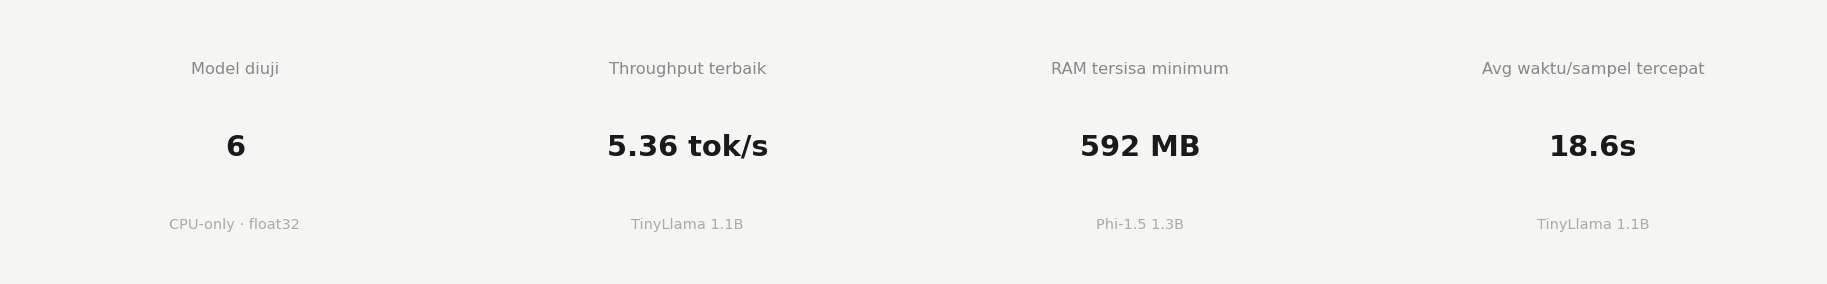

Tersimpan: results/figures/01_summary_cards.png


In [3]:
fig, axes = plt.subplots(1, 4, figsize=(14, 2.2))
fig.patch.set_facecolor("#F5F5F3")

metrics = [
    ("Model diuji",            str(len(df)),                        "CPU-only · float32"),
    ("Throughput terbaik",     f"{df.tokens_per_sec.max():.2f} tok/s",
                                df.loc[df.tokens_per_sec.idxmax(), 'label'].replace('\n',' ')),
    ("RAM tersisa minimum",    f"{df.ram_available_mb.min():.0f} MB",
                                df.loc[df.ram_available_mb.idxmin(), 'label'].replace('\n',' ')),
    ("Avg waktu/sampel tercepat", f"{df.avg_time_per_sample_s.min():.1f}s",
                                df.loc[df.avg_time_per_sample_s.idxmin(), 'label'].replace('\n',' ')),
]

for ax, (title, value, sub) in zip(axes, metrics):
    ax.set_facecolor("white")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis("off")
    ax.text(0.5, 0.78, title, ha="center", va="center", fontsize=9, color="#888")
    ax.text(0.5, 0.48, value, ha="center", va="center", fontsize=16, fontweight="bold", color="#1a1a1a")
    ax.text(0.5, 0.18, sub,   ha="center", va="center", fontsize=8,  color="#aaa")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color("#ddd")

plt.suptitle("", y=1)
plt.tight_layout(pad=0.5)
plt.savefig("../results/figures/01_summary_cards.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Tersimpan: results/figures/01_summary_cards.png")


## Perbandingan Resource per Model

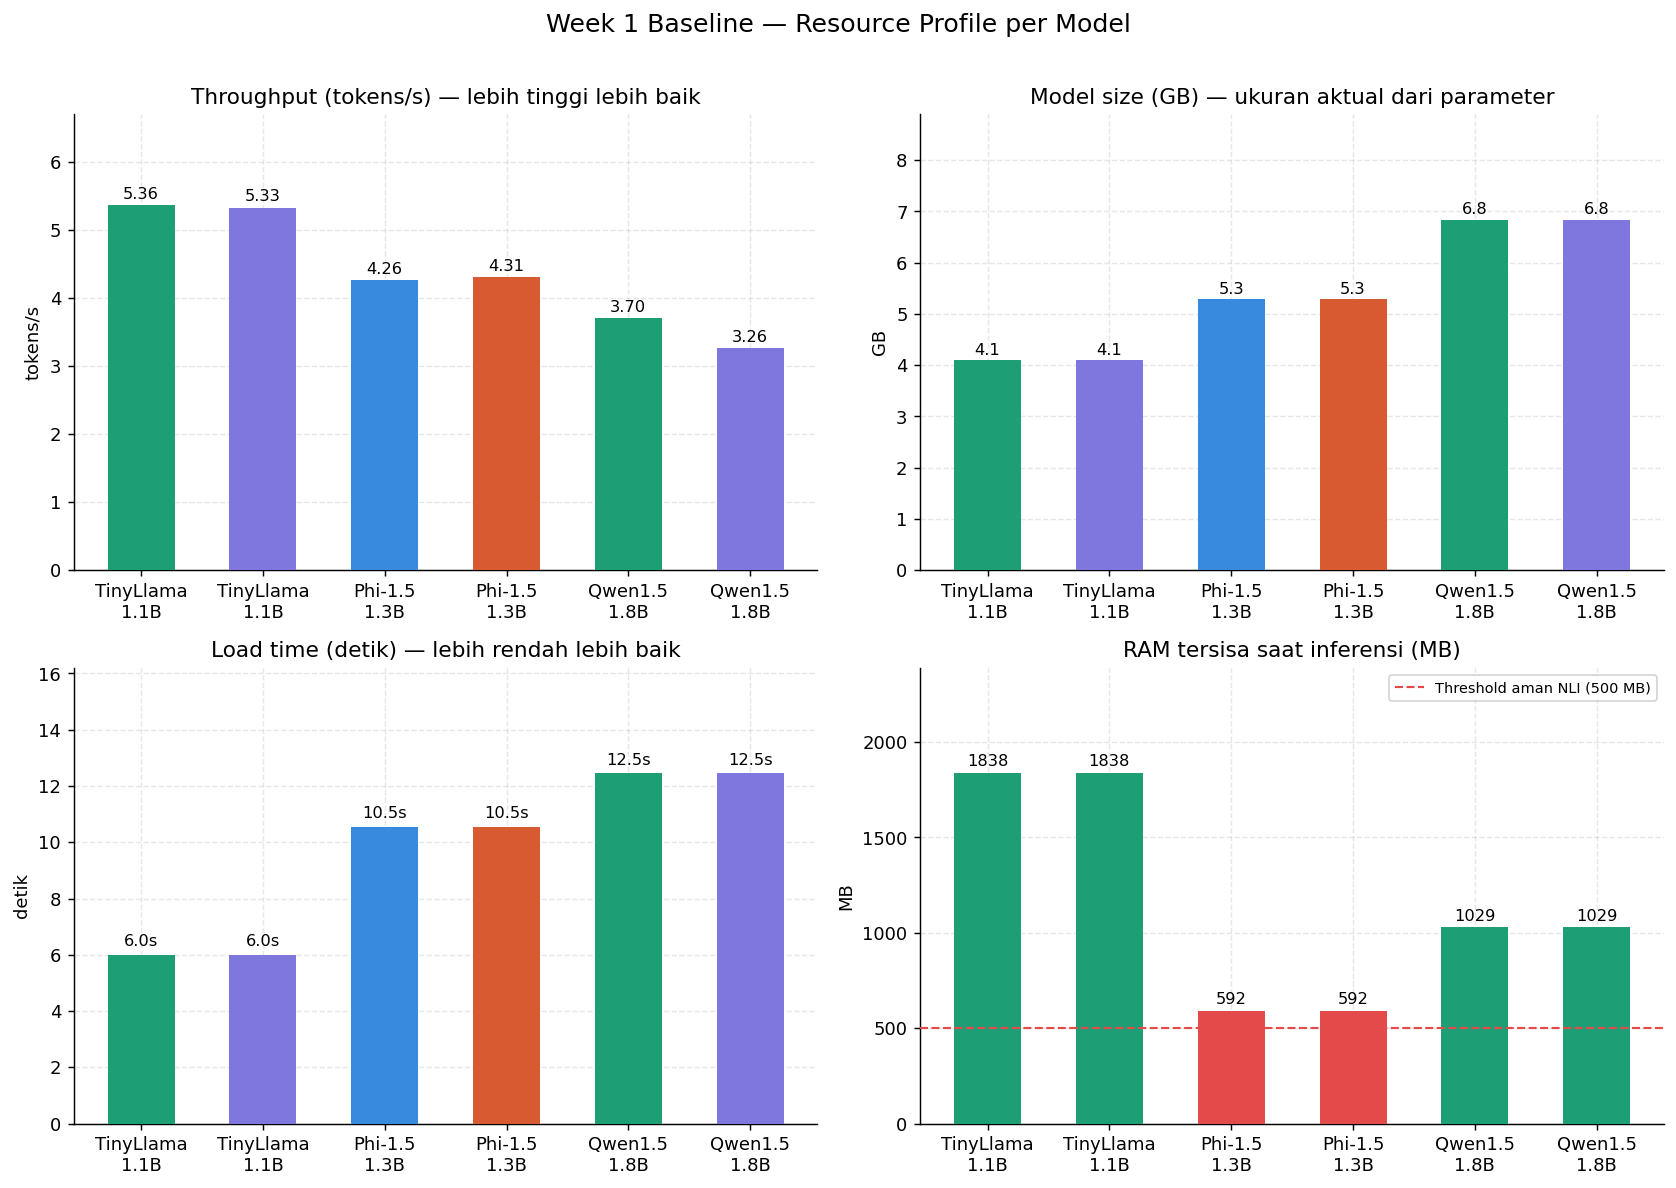

Tersimpan: results/figures/02_resource_charts.png


In [4]:
# Path("results/figures").mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Week 1 Baseline — Resource Profile per Model", fontsize=14, fontweight="normal", y=1.01)

labels = df["label"].tolist()
x = np.arange(len(labels))
bar_w = 0.55

# ── 1. Throughput
ax = axes[0][0]
bars = ax.bar(x, df["tokens_per_sec"], width=bar_w, color=COLORS, zorder=3, linewidth=0)
ax.set_title("Throughput (tokens/s) — lebih tinggi lebih baik")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("tokens/s")
for bar, val in zip(bars, df["tokens_per_sec"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05, f"{val:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, df["tokens_per_sec"].max() * 1.25)

# ── 2. Model size
ax = axes[0][1]
bars = ax.bar(x, df["model_size_mb"] / 1024, width=bar_w, color=COLORS, zorder=3, linewidth=0)
ax.set_title("Model size (GB) — ukuran aktual dari parameter")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("GB")
for bar, val in zip(bars, df["model_size_mb"] / 1024):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05, f"{val:.1f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, (df["model_size_mb"] / 1024).max() * 1.3)

# ── 3. Load time
ax = axes[1][0]
bars = ax.bar(x, df["load_time_s"], width=bar_w, color=COLORS, zorder=3, linewidth=0)
ax.set_title("Load time (detik) — lebih rendah lebih baik")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("detik")
for bar, val in zip(bars, df["load_time_s"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.2, f"{val:.1f}s", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, df["load_time_s"].max() * 1.3)

# ── 4. RAM tersisa
ax = axes[1][1]
colors_ram = ["#E24B4A" if v < 600 else "#EF9F27" if v < 1000 else "#1D9E75"
              for v in df["ram_available_mb"]]
bars = ax.bar(x, df["ram_available_mb"], width=bar_w, color=colors_ram, zorder=3, linewidth=0)
ax.axhline(500, color="#E24B4A", linestyle="--", linewidth=1.2, zorder=4, label="Threshold aman NLI (500 MB)")
ax.set_title("RAM tersisa saat inferensi (MB)")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("MB")
for bar, val in zip(bars, df["ram_available_mb"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 20, f"{val:.0f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, df["ram_available_mb"].max() * 1.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../results/figures/02_resource_charts.png", bbox_inches="tight")
plt.show()
print("Tersimpan: results/figures/02_resource_charts.png")


## Trade-off: Model Size vs Throughput

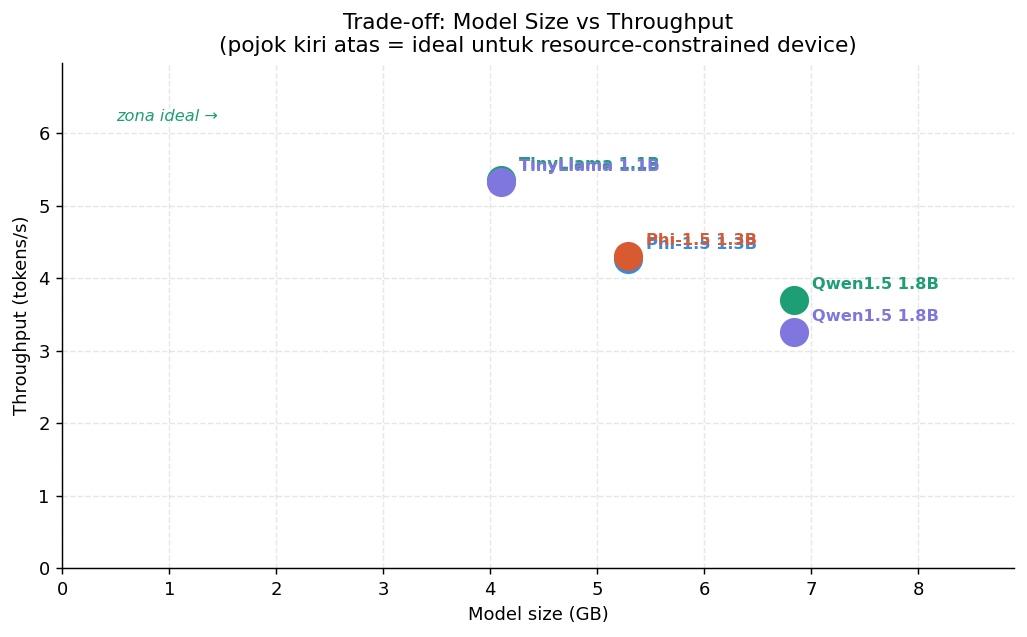

Tersimpan: results/figures/03_tradeoff_scatter.png


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

for i, row in df.iterrows():
    size_gb = row["model_size_mb"] / 1024
    tps     = row["tokens_per_sec"]
    color   = COLORS[i % len(COLORS)]
    label   = row["label"].replace("\n", " ")

    ax.scatter(size_gb, tps, s=260, color=color, zorder=5, linewidth=0)
    ax.annotate(label, xy=(size_gb, tps),
                xytext=(10, 6), textcoords="offset points",
                fontsize=9, color=color, fontweight="bold")

ax.set_xlabel("Model size (GB)")
ax.set_ylabel("Throughput (tokens/s)")
ax.set_title("Trade-off: Model Size vs Throughput\n(pojok kiri atas = ideal untuk resource-constrained device)")
ax.set_xlim(0, df["model_size_mb"].max() / 1024 * 1.3)
ax.set_ylim(0, df["tokens_per_sec"].max() * 1.3)

# Ideal zone annotation
ax.annotate("zona ideal →", xy=(0.5, df["tokens_per_sec"].max() * 1.15),
            fontsize=9, color="#1D9E75", style="italic")

plt.tight_layout()
plt.savefig("../results/figures/03_tradeoff_scatter.png", bbox_inches="tight")
plt.show()
print("Tersimpan: results/figures/03_tradeoff_scatter.png")


## Tabel Lengkap — Semua Metrik

In [6]:
display_cols = {
    "label":                  "Model",
    "model_size_mb":          "Size (MB)",
    "load_time_s":            "Load (s)",
    "tokens_per_sec":         "Throughput (tok/s)",
    "avg_tokens_per_sample":  "Avg tokens/sampel",
    "avg_time_per_sample_s":  "Avg time/sampel (s)",
    "gen_time_s":             "Total gen time (s)",
    "ram_after_load_mb":      "RAM after load (MB)",
    "ram_available_mb":       "RAM tersisa (MB)",
}

summary = df[list(display_cols.keys())].rename(columns=display_cols)

def color_throughput(val):
    if val >= 4:    return "background-color: #EAF3DE; color: #27500A"
    elif val >= 2.5: return "background-color: #FAEEDA; color: #633806"
    else:           return "background-color: #FCEBEB; color: #791F1F"

def color_ram(val):
    if val >= 1000: return "background-color: #EAF3DE; color: #27500A"
    elif val >= 600: return "background-color: #FAEEDA; color: #633806"
    else:           return "background-color: #FCEBEB; color: #791F1F"

styled = (summary.style
    .applymap(color_throughput, subset=["Throughput (tok/s)"])
    .applymap(color_ram,        subset=["RAM tersisa (MB)"])
    .format({
        "Size (MB)":             "{:,.0f}",
        "Load (s)":              "{:.2f}",
        "Throughput (tok/s)":    "{:.2f}",
        "Avg tokens/sampel":     "{:.1f}",
        "Avg time/sampel (s)":   "{:.2f}",
        "Total gen time (s)":    "{:.1f}",
        "RAM after load (MB)":   "{:,.0f}",
        "RAM tersisa (MB)":      "{:,.0f}",
    })
    .set_table_styles([
        {"selector": "th", "props": [("font-size", "11px"), ("text-align", "left"),
                                      ("background-color", "#f5f5f5")]},
        {"selector": "td", "props": [("font-size", "12px")]},
    ])
)
display(styled)


C:\Users\stiev\AppData\Local\Temp\ipykernel_20484\136461020.py:25: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled = (summary.style


,Model,Size (MB),Load (s),Throughput (tok/s),Avg tokens/sampel,Avg time/sampel (s),Total gen time (s),RAM after load (MB),RAM tersisa (MB)
0,TinyLlama 1.1B,"4,196",6.00,5.36,100.0,18.64,186.4,"2,533","1,838"
1,TinyLlama 1.1B,"4,196",6.00,5.33,100.0,18.75,187.5,"2,533","1,838"
2,Phi-1.5 1.3B,"5,410",10.55,4.26,100.0,23.45,234.5,456,592
3,Phi-1.5 1.3B,"5,410",10.55,4.31,100.0,23.21,232.1,456,592
4,Qwen1.5 1.8B,"7,007",12.46,3.70,100.0,27.04,270.4,719,"1,029"
5,Qwen1.5 1.8B,"7,007",12.46,3.26,100.0,30.66,306.6,719,"1,029"


## Temuan Utama Week 1

| # | Temuan | Implikasi untuk Week 2 |
|---|--------|------------------------|
| 1 | **TinyLlama** paling efisien: throughput tertinggi, size terkecil, RAM tersisa terbanyak | Kandidat utama untuk eksperimen awal |
| 2 | **Qwen1.5** RAM tersisa kritis (<600 MB) | Wajib load/unload bergantian dengan NLI model |
| 3 | Semua model berjalan di float32 (CPU) | Potensi penghematan besar dengan INT4/INT8 di Week 3 |
| 4 | Rata-rata 20–55 detik per query dengan M=10 | TriviaQA dengan 200 soal × 3 model = estimasi 3–5 jam |


In [7]:
print("=" * 55)
print("FILE TERSIMPAN")
print("=" * 55)
print(f"  CSV    : {CSV_PATH}")
print(f"  Chart 1: results/figures/01_summary_cards.png")
print(f"  Chart 2: results/figures/02_resource_charts.png")
print(f"  Chart 3: results/figures/03_tradeoff_scatter.png")
print()
print("Semua angka ini adalah baseline resmi Week 1.")
print("Gunakan sebagai pembanding di Week 3 (quantization).")


FILE TERSIMPAN
  CSV    : ../results/metrics/baseline_metrics.csv
  Chart 1: results/figures/01_summary_cards.png
  Chart 2: results/figures/02_resource_charts.png
  Chart 3: results/figures/03_tradeoff_scatter.png

Semua angka ini adalah baseline resmi Week 1.
Gunakan sebagai pembanding di Week 3 (quantization).
